In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# LRT Line and Stations — Stop-to-Stop Travel Times, Underground vs Ground-Level Scenarios

Geometry of the planned line **`Input/GeneralHalufa/hf_lrt_3.shp`** (one polyline, WGS 84) and its stations **`station_hf_lrt_3.geojson`** (46 platform points), turned into a station table with chainage, inter-station distances and TAZ / V2-area membership, and into **station-to-station in-vehicle travel-time matrices** under two scenarios.

**Travel-time function.** The calibrated transit in-vehicle time function of the *Transit In-Vehicle Travel Time Calibration Report* (OperatorRef 22, Thursdays May 2023 – September 2026; 26,653 clean complete journeys, 799,590 stop-to-stop sections):

`T_trip [min] = 1.960792 × N_UG + 2.392690 × N_Other`

per 500 m section, i.e. in distance form `T [min] = 3.921585 × D_UG + 4.785381 × D_Other` (D in km), equivalent commercial speeds **15.30 km/h underground** and **12.54 km/h at ground level** (elapsed stop-to-stop time, dwell included). The report's classification rule makes a section underground only when both its end stations are underground, so the two scenarios asked for — **all stations underground** and **all stations at ground level** — are the two pure regimes: every section takes the underground coefficient in the first and the other coefficient in the second.

**Two forms, kept as a pair.** The coefficients were calibrated on a fixed 500 m section; the spacing here averages ≈ 810 m. The **distance form** (report §6) scales the elapsed time with the actual inter-station distance and is the primary estimate; the **section form** (one section per inter-station link whatever its length) is kept as the lower bound, since running time grows with distance but dwell does not. The report's own recommendation is to re-estimate running and dwell separately when actual spacing matters; until then the pair brackets the answer.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile
from pyproj import Transformer
from shapely.geometry import LineString, Point, shape
from shapely.strtree import STRtree

BLUE, ORANGE, AQUA, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/lrt_v2'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
# ---- calibrated coefficients (report §6) ----
COEF_SECTION = {'underground': 1.960792, 'ground': 2.392690}        # min per 500 m section
COEF_KM = {k: v / 0.5 for k, v in COEF_SECTION.items()}              # min per km: 3.921585 / 4.785381
SPEED = {k: 60 / v for k, v in COEF_KM.items()}                      # km/h: 15.30 / 12.54
SCEN = {'all_underground': 'underground', 'all_ground': 'ground'}
print({k: round(v, 4) for k, v in COEF_KM.items()}, {k: round(v, 2) for k, v in SPEED.items()})

# ---- geometry: WGS 84 -> Israel TM Grid (EPSG:2039), the CRS of the TAZ shapefile ----
to_itm = Transformer.from_crs('EPSG:4326', 'EPSG:2039', always_xy=True); to_wgs = Transformer.from_crs('EPSG:2039', 'EPSG:4326', always_xy=True)
line_shp = shapefile.Reader('Input/GeneralHalufa/hf_lrt_3'); assert len(line_shp) == 1
L = LineString([to_itm.transform(x, y) for x, y in line_shp.shape(0).points]); LEN = L.length
gj = json.load(open('Input/GeneralHalufa/station_hf_lrt_3.geojson'))
pts = pd.DataFrame([{'point': i, 'halufa': f['properties']['halufa'], 'lon': f['geometry']['coordinates'][0], 'lat': f['geometry']['coordinates'][1]} for i, f in enumerate(gj['features'])])
pts[['x', 'y']] = [to_itm.transform(lo, la) for lo, la in zip(pts['lon'], pts['lat'])]
pts['chain_from_file_start'] = [L.project(Point(x, y)) for x, y in zip(pts['x'], pts['y'])]
pts['offset_m'] = [L.distance(Point(x, y)) for x, y in zip(pts['x'], pts['y'])]
# the polyline runs from Hamifrats (file start) to Tirat Carmel; chainage is measured from the Tirat Carmel end to match the route order of the V2 aggregation (up = away from Tirat Carmel)
pts['chainage_m'] = LEN - pts['chain_from_file_start']
pts = pts.sort_values('chainage_m').reset_index(drop=True)
# ---- platform points -> stations: consecutive points closer than 150 m along the line are one station (22 pairs + 2 single points) ----
grp = [0]
for k in range(1, len(pts)): grp.append(grp[-1] + int(pts['chainage_m'][k] - pts['chainage_m'][k - 1] > 150))
pts['station_no'] = np.array(grp) + 1
st = pts.groupby('station_no').agg(chainage_m=('chainage_m', 'mean'), x=('x', 'mean'), y=('y', 'mean'), n_points=('point', 'size'), max_offset_m=('offset_m', 'max'), halufa=('halufa', lambda s: '/'.join(sorted({str(int(v)) for v in s if pd.notna(v)})) or '')).reset_index()
st['station_id'] = [f'S{n:02d}' for n in st['station_no']]
st[['lon', 'lat']] = [to_wgs.transform(x, y) for x, y in zip(st['x'], st['y'])]
# ---- TAZ and V2 area of each station ----
tz = shapefile.Reader('Input/TAZ_North/TAZ_North'); polys = [shape(s.__geo_interface__) for s in tz.shapes()]; taz_ids = [r['TAZ_NUMBER'] for r in tz.records()]; tree = STRtree(polys)
def taz_at(x, y):
    hit = tree.query(Point(x, y), predicate='within'); return int(taz_ids[hit[0]]) if len(hit) else None
st['TAZ'] = [taz_at(x, y) for x, y in zip(st['x'], st['y'])]
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx'); areas = xl.parse('AreaCodes').set_index('AggCode'); key = xl.parse('TazAgg').set_index('TAZ')['AggCode']
st['AggCode'] = st['TAZ'].map(key); st['AggAreaName'] = st['AggCode'].map(areas['AggAreaName'])
st['dist_to_next_m'] = st['chainage_m'].shift(-1) - st['chainage_m']
st['dist_from_prev_m'] = st['chainage_m'].diff()
assert st['n_points'].sum() == len(pts) == 46 and st['max_offset_m'].max() < 100, 'every platform point must sit on the line'
print(f"line length {LEN / 1000:.2f} km, {len(st)} stations from chainage {st['chainage_m'].min():,.0f} m to {st['chainage_m'].max():,.0f} m; "
      f"mean spacing {st['dist_to_next_m'].mean():,.0f} m (min {st['dist_to_next_m'].min():,.0f}, max {st['dist_to_next_m'].max():,.0f}); "
      f"stations without a V2 area: {st['AggCode'].isna().sum()} (TAZ {st.loc[st['AggCode'].isna(), 'TAZ'].tolist()})")
cols = ['station_id', 'chainage_m', 'dist_to_next_m', 'TAZ', 'AggCode', 'AggAreaName', 'n_points', 'max_offset_m', 'halufa', 'x', 'y', 'lon', 'lat']
st['TAZ'] = st['TAZ'].astype('Int64'); st['AggCode'] = st['AggCode'].astype('Int64')
st[cols].round({'chainage_m': 1, 'dist_to_next_m': 1, 'max_offset_m': 1, 'x': 1, 'y': 1, 'lon': 7, 'lat': 7}).to_csv(f'{OUT}/lrt_stations_hf_lrt_3.csv', index=False)
json.dump({'type': 'FeatureCollection', 'name': 'lrt_stations_hf_lrt_3', 'features': [{'type': 'Feature', 'properties': {c: (None if pd.isna(r[c]) else (float(r[c]) if isinstance(r[c], (float, np.floating)) else (int(r[c]) if isinstance(r[c], (np.integer,)) else r[c]))) for c in cols if c not in ('x', 'y', 'lon', 'lat')}, 'geometry': {'type': 'Point', 'coordinates': [round(r['lon'], 7), round(r['lat'], 7)]}} for _, r in st.iterrows()]}, open(f'{OUT}/lrt_stations_hf_lrt_3.geojson', 'w'), ensure_ascii=False, indent=1)
st[cols[:9]].round(0)

{'underground': 3.9216, 'ground': 4.7854} {'underground': 15.3, 'ground': 12.54}


line length 18.94 km, 24 stations from chainage 165 m to 18,908 m; mean spacing 815 m (min 354, max 1,396); stations without a V2 area: 1 (TAZ [1509])


,station_id,chainage_m,dist_to_next_m,TAZ,AggCode,AggAreaName,n_points,max_offset_m,halufa
0,S01,165.0,1247.0,2413,201,TiratCarmel,2,18.0,999
1,S02,1412.0,1058.0,2421,201,TiratCarmel,2,13.0,1
2,S03,2470.0,749.0,2402,201,TiratCarmel,2,36.0,1
3,S04,3219.0,1102.0,2408,201,TiratCarmel,2,16.0,999
4,S05,4322.0,778.0,2401,202,Matam-NeotPeres,2,16.0,999
5,S06,5100.0,621.0,1517,202,Matam-NeotPeres,2,17.0,999
6,S07,5720.0,511.0,1517,202,Matam-NeotPeres,2,12.0,
7,S08,6231.0,1173.0,1520,203,HofCarmel-NeveDavid,2,26.0,
8,S09,7404.0,1396.0,1514,203,HofCarmel-NeveDavid,2,13.0,2
9,S10,8800.0,434.0,1512,204,Hecht-Shprintzak,2,8.0,


## 1. Station-to-station in-vehicle times under the two scenarios

In [3]:
n = len(st); chain = st['chainage_m'].values / 1000; ids = list(st['station_id'])
D = np.abs(chain[:, None] - chain[None, :])                          # km along the line between stations
NSEC = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :])          # number of inter-station sections
T = {}
for sc, regime in SCEN.items():
    T[(sc, 'distance')] = pd.DataFrame(D * COEF_KM[regime], index=ids, columns=ids)
    T[(sc, 'section')] = pd.DataFrame(NSEC * COEF_SECTION[regime], index=ids, columns=ids)
    T[(sc, 'distance')].to_csv(f'{OUT}/lrt_station_times_{sc}.csv', float_format='%.2f')
    T[(sc, 'section')].to_csv(f'{OUT}/lrt_station_times_{sc}_section_form.csv', float_format='%.2f')
pd.DataFrame(D, index=ids, columns=ids).to_csv(f'{OUT}/lrt_station_distances_km.csv', float_format='%.3f')
# line profile: cumulative time from S01 under each scenario and form
prof = st[['station_id', 'chainage_m', 'dist_to_next_m', 'AggAreaName']].copy()
for sc, regime in SCEN.items():
    prof[f'cum_min_{sc}'] = (prof['chainage_m'] - prof['chainage_m'].iloc[0]) / 1000 * COEF_KM[regime]
    prof[f'cum_min_{sc}_section_form'] = np.arange(n) * COEF_SECTION[regime]
    prof[f'section_min_{sc}'] = prof['dist_to_next_m'] / 1000 * COEF_KM[regime]
prof.to_csv(f'{OUT}/lrt_line_profile.csv', index=False, float_format='%.2f')
end = {sc: (T[(sc, 'distance')].iloc[0, -1], T[(sc, 'section')].iloc[0, -1]) for sc in SCEN}
span = chain[-1] - chain[0]
print(f"end to end S01 → S{n:02d}: {span:.2f} km, {n - 1} sections")
for sc in SCEN: print(f"  {sc:16s}: distance form {end[sc][0]:5.1f} min ({span / end[sc][0] * 60:.1f} km/h)   section form {end[sc][1]:5.1f} min ({span / end[sc][1] * 60:.1f} km/h)")
print(f"  underground saves {(1 - COEF_KM['underground'] / COEF_KM['ground']) * 100:.1f} % of in-vehicle time on every pair (both forms)")
prof.round(1)

end to end S01 → S24: 18.74 km, 23 sections
  all_underground : distance form  73.5 min (15.3 km/h)   section form  45.1 min (24.9 km/h)
  all_ground      : distance form  89.7 min (12.5 km/h)   section form  55.0 min (20.4 km/h)
  underground saves 18.1 % of in-vehicle time on every pair (both forms)


,station_id,chainage_m,dist_to_next_m,AggAreaName,cum_min_all_underground,cum_min_all_underground_section_form,section_min_all_underground,cum_min_all_ground,cum_min_all_ground_section_form,section_min_all_ground
0,S01,164.9,1247.4,TiratCarmel,0.0,0.0,4.9,0.0,0.0,6.0
1,S02,1412.3,1058.1,TiratCarmel,4.9,2.0,4.1,6.0,2.4,5.1
2,S03,2470.5,748.9,TiratCarmel,9.0,3.9,2.9,11.0,4.8,3.6
3,S04,3219.4,1102.1,TiratCarmel,12.0,5.9,4.3,14.6,7.2,5.3
4,S05,4321.5,778.0,Matam-NeotPeres,16.3,7.8,3.1,19.9,9.6,3.7
5,S06,5099.5,620.7,Matam-NeotPeres,19.4,9.8,2.4,23.6,12.0,3.0
6,S07,5720.2,510.8,Matam-NeotPeres,21.8,11.8,2.0,26.6,14.4,2.4
7,S08,6231.0,1173.0,HofCarmel-NeveDavid,23.8,13.7,4.6,29.0,16.7,5.6
8,S09,7404.0,1396.3,HofCarmel-NeveDavid,28.4,15.7,5.5,34.6,19.1,6.7
9,S10,8800.3,433.8,Hecht-Shprintzak,33.9,17.6,1.7,41.3,21.5,2.1


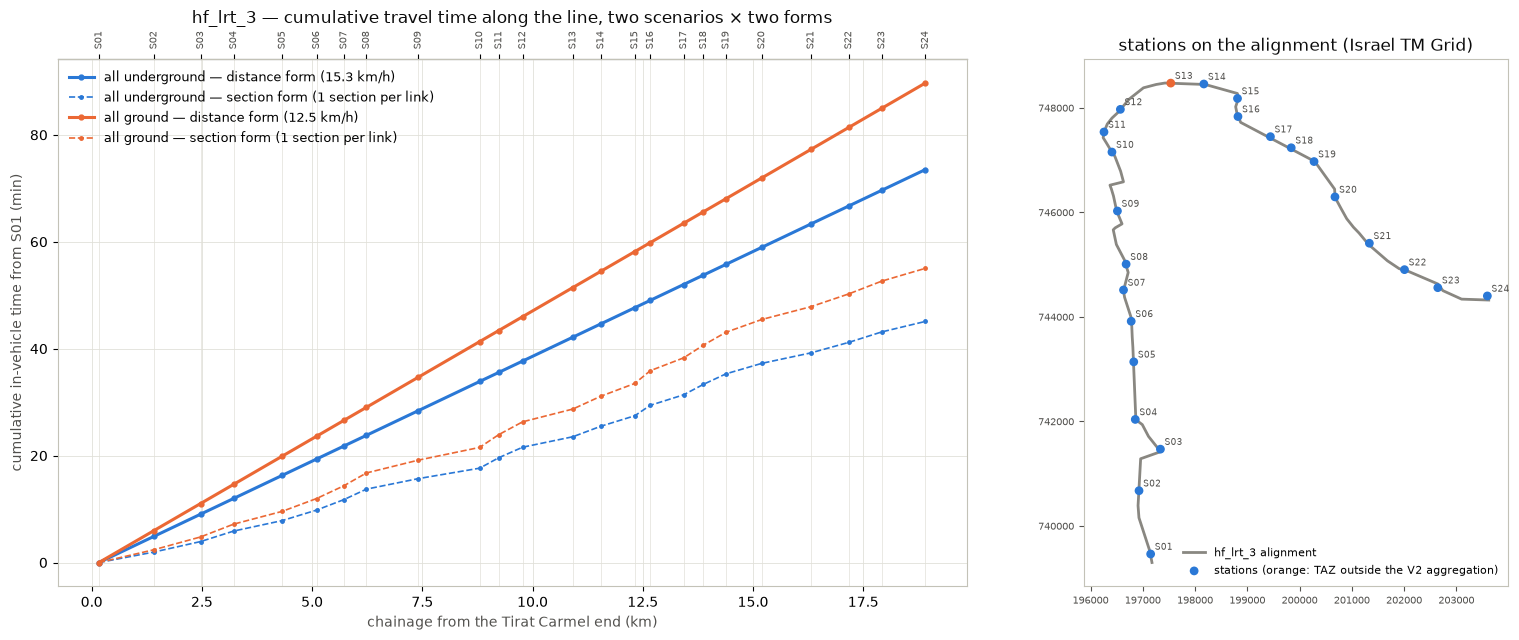

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor='white', gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
for sc, color in [('all_underground', BLUE), ('all_ground', ORANGE)]:
    ax.plot(prof['chainage_m'] / 1000, prof[f'cum_min_{sc}'], color=color, lw=2.2, marker='o', ms=3.5, label=f'{sc.replace("_", " ")} — distance form ({SPEED[SCEN[sc]]:.1f} km/h)')
    ax.plot(prof['chainage_m'] / 1000, prof[f'cum_min_{sc}_section_form'], color=color, lw=1.2, ls='--', marker='o', ms=2.5, label=f'{sc.replace("_", " ")} — section form (1 section per link)')
for _, r in prof.iterrows(): ax.axvline(r['chainage_m'] / 1000, color=GRID, lw=0.5, zorder=0)
ax.set_xlabel('chainage from the Tirat Carmel end (km)', color=INK2); ax.set_ylabel('cumulative in-vehicle time from S01 (min)', color=INK2)
ax.set_title('hf_lrt_3 — cumulative travel time along the line, two scenarios × two forms', color=INK, fontsize=12); ax.legend(frameon=False, fontsize=9)
ax.grid(True, color=GRID, lw=0.6); [s.set_color(AXIS) for s in ax.spines.values()]
sec = ax.secondary_xaxis('top'); sec.set_xticks(prof['chainage_m'] / 1000); sec.set_xticklabels(prof['station_id'], fontsize=7, rotation=90, color=INK2)
ax = axes[1]
ax.plot(L.xy[0], L.xy[1], color=MUTED, lw=2, label='hf_lrt_3 alignment')
ax.scatter(st['x'], st['y'], c=[BLUE if pd.notna(a) else ORANGE for a in st['AggCode']], s=28, zorder=3, label='stations (orange: TAZ outside the V2 aggregation)')
for _, r in st.iterrows(): ax.annotate(r['station_id'], (r['x'], r['y']), fontsize=6.5, color=INK2, xytext=(3, 3), textcoords='offset points')
ax.set_aspect('equal'); ax.set_title('stations on the alignment (Israel TM Grid)', color=INK, fontsize=12); ax.legend(frameon=False, fontsize=8, loc='lower right'); ax.tick_params(labelsize=7, colors=INK2)
[s.set_color(AXIS) for s in ax.spines.values()]
plt.tight_layout(); fig.savefig('Output/figures/lrt_line_profile_hf_lrt_3.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## 2. Area-to-area LRT in-vehicle times (V2 trunk areas served by the line)

For the generalized-cost matrix an area pair needs one in-vehicle time. Each V2 area on the line is represented by the **station nearest its population + employment weighted centroid** (TAZ centroids weighted by 2020 residents + jobs); the area-pair IVT is the station-to-station time. The line as drawn ends at Hamifrats: **Bazan-Hutsot (211), Tsomet Kiryat Ata (212) and the three branches have no station on `hf_lrt_3`**, so their LRT times cannot be produced from this geometry — they are recorded as missing in the generalized-cost inventory (step 26).

In [5]:
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID')
cent = {int(r['TAZ_NUMBER']): p.centroid for p, r in zip(polys, tz.records())}
k = xl.parse('TazAgg'); k['cx'] = [cent[t].x for t in k['TAZ']]; k['cy'] = [cent[t].y for t in k['TAZ']]
k['w'] = zon.reindex(k['TAZ'])['POPULATION'].fillna(0).values + zon.reindex(k['TAZ'])['EMPL_TOT'].fillna(0).values; k.loc[k['w'] <= 0, 'w'] = 1
ac = k.groupby('AggCode').apply(lambda g: pd.Series({'cx': np.average(g['cx'], weights=g['w']), 'cy': np.average(g['cy'], weights=g['w'])}), include_groups=False)
ac['AggAreaName'] = areas['AggAreaName']
stxy = st[['x', 'y']].values
ac['nearest_station'] = [ids[int(np.argmin(np.hypot(stxy[:, 0] - x, stxy[:, 1] - y)))] for x, y in zip(ac['cx'], ac['cy'])]
ac['dist_centroid_to_station_m'] = [np.min(np.hypot(stxy[:, 0] - x, stxy[:, 1] - y)) for x, y in zip(ac['cx'], ac['cy'])]
ac['on_line'] = ac.index.isin(st['AggCode'].dropna().astype(int))
ac.to_csv(f'{OUT}/lrt_area_representative_station.csv', float_format='%.1f')
served = [a for a in ac.index if ac.loc[a, 'on_line']]
for sc in SCEN:
    M = pd.DataFrame([[T[(sc, 'distance')].loc[ac.loc[o, 'nearest_station'], ac.loc[d, 'nearest_station']] for d in served] for o in served], index=served, columns=served)
    M.to_csv(f'{OUT}/lrt_area_ivt_{sc}.csv', float_format='%.2f')
print(f"areas served by a station on hf_lrt_3: {len(served)} — " + ', '.join(f'{a} {areas.loc[a, "AggAreaName"]} ({ac.loc[a, "nearest_station"]})' for a in served))
print("not served by this geometry: " + ', '.join(f'{a} {areas.loc[a, "AggAreaName"]}' for a in ac.index if not ac.loc[a, 'on_line']))
pd.read_csv(f'{OUT}/lrt_area_ivt_all_underground.csv', index_col=0).round(1)

areas served by a station on hf_lrt_3: 10 — 201 TiratCarmel (S02), 202 Matam-NeotPeres (S06), 203 HofCarmel-NeveDavid (S09), 204 Hecht-Shprintzak (S10), 205 EinHayam (S12), 206 BatGalim-KiryatEliezer (S15), 207 Hamoshava (S17), 208 LowerCity (S19), 209 Namal-Giborim (S21), 210 Hamifrats (S24)
not served by this geometry: 101 TsurShalom, 102 Kiryon, 103 KiryatBialik Center, 104 KiryatHaim, 211 Bazan-Hutsot, 212 TsometKiryatAta, 213 KiryatAta North, 214 KiryatAta North-East, 215 Shefaram, 216 Hamovil, 217 Nazareth, 301 SavyoneyYam, 302 KiryatYam A, 303 KiryatYam B+C, 304 KiryatHaim West


,201,202,203,204,205,206,207,208,209,210
201,0.0,14.5,23.5,29.0,32.8,42.8,47.1,50.9,58.4,68.6
202,14.5,0.0,9.0,14.5,18.3,28.3,32.6,36.4,44.0,54.2
203,23.5,9.0,0.0,5.5,9.3,19.3,23.6,27.4,34.9,45.1
204,29.0,14.5,5.5,0.0,3.8,13.8,18.1,21.9,29.5,39.6
205,32.8,18.3,9.3,3.8,0.0,10.0,14.3,18.1,25.6,35.8
206,42.8,28.3,19.3,13.8,10.0,0.0,4.4,8.1,15.7,25.8
207,47.1,32.6,23.6,18.1,14.3,4.4,0.0,3.8,11.3,21.5
208,50.9,36.4,27.4,21.9,18.1,8.1,3.8,0.0,7.6,17.7
209,58.4,44.0,34.9,29.5,25.6,15.7,11.3,7.6,0.0,10.2
210,68.6,54.2,45.1,39.6,35.8,25.8,21.5,17.7,10.2,0.0


## Findings

- **Geometry.** `hf_lrt_3` is one 18.94 km polyline from Hamifrats to Tirat Carmel; the 46 platform points form **24 stations** (22 platform pairs and two single points at the Hamifrats end), all within 80 m of the alignment, spanning 18.74 km between S01 (Tirat Carmel south) and S24 (Hamifrats). Mean spacing 815 m (354 m to 1,396 m) — 1.6 × the 500 m section the coefficients were calibrated on. One station (S13, TAZ 1509 between Ein Hayam and Bat Galim) falls in a TAZ that the V2 aggregation does not list; it should be added to area 206 or 205 in `Corridor_TAZ_Agg_V2.xlsx`.
- **End-to-end in-vehicle time, S01 → S24 (18.74 km, 23 sections).** All underground: **73.5 min** in the distance form (15.3 km/h) and 45.1 min in the section form (24.9 km/h). All ground level: **89.7 min** (12.5 km/h) and 55.0 min (20.4 km/h). Underground saves 18.1 % of in-vehicle time on every station pair, in both forms and both scenarios, because the two coefficients differ by that ratio.
- **Which form.** The calibrated coefficients are elapsed stop-to-stop times at 500 m spacing, dwell included. Stretched over 815 m spacing the distance form charges dwell 1.6 times per kilometre and gives the slow end; the section form keeps one dwell per stop but no extra running time for the longer sections and gives the fast end. The truth for this line sits between, closer to the section form on the long Carmel-coast sections and closer to the distance form in the dense city-centre stretch; a running-time / dwell decomposition (the report's own recommended refinement) would replace the pair. Both forms are published; the distance form is carried into the generalized-cost inventory (step 26) as the primary value with the section form as the sensitivity.
- **Against the earlier assumption.** `docs/LRT_CAPTURE_PLAN.md` assumed a 22–26 km/h commercial speed; the calibrated function gives 12.5–15.3 km/h (distance form) or 20–25 km/h (section form). The plan's speed sits at the section-form end.
- **Area coverage.** The line serves the ten trunk areas 201–210 (Tirat Carmel to Hamifrats), each represented by the station nearest its weighted centroid (S02, S06, S09, S10, S12, S15, S17, S19, S21, S24). Bazan-Hutsot (211), Tsomet Kiryat Ata (212) and the three V2 branches (Kiryat Ata – Nazareth, Krayot, Kiryat Yam) have no station on this geometry: their LRT skims need the branch alignments and stations to be drawn.
- **Outputs.** `Output/lrt_v2/lrt_stations_hf_lrt_3.csv` / `.geojson` (station table with chainage, TAZ, V2 area), `lrt_station_distances_km.csv`, `lrt_station_times_{all_underground,all_ground}.csv` (distance form) and `…_section_form.csv`, `lrt_line_profile.csv`, `lrt_area_representative_station.csv`, `lrt_area_ivt_{all_underground,all_ground}.csv`; figure `lrt_line_profile_hf_lrt_3.png`.